# Modelo de Stacking — Detección de Fraude en Tarjetas de Crédito

**Objetivo:** Entrenar y validar un modelo de Stacking para la detección de transacciones fraudulentas.  
**Entrada:** `df_train.csv` y `df_test.csv` generados en el notebook de EDA (ya preprocesados).  

**Estructura:**
1. Librerías y carga de datos
2. Definición del modelo de Stacking (6 modelos base + metamodelo)
3. Entrenamiento
4. Evaluación del Stacking
5. Comparativa: modelos base individuales vs Stacking
6. Visualizaciones: Curva ROC, PR, Matriz de Confusión, Importancia de variables

## 1. Librerías

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings


# Modelos base
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB



# Métricas
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    f1_score, accuracy_score, matthews_corrcoef, average_precision_score
)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

RANDOM_STATE = 42
print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 2. Carga de datos

Cargamos directamente los datasets ya preprocesados por el notebook de EDA.  
**No se aplica ninguna transformación adicional** — el escalado y el encoding ya fueron realizados y el preprocesador se ajustó exclusivamente sobre el conjunto de entrenamiento.

In [3]:
df_train = pd.read_csv('../data/df_train.csv')
df_test  = pd.read_csv('../data/df_test.csv')

feature_cols = [c for c in df_train.columns if c != 'is_fraud']

X_train = df_train[feature_cols]
y_train = df_train['is_fraud']
X_test  = df_test[feature_cols]
y_test  = df_test['is_fraud']

print(f'Train: {X_train.shape[0]:,} muestras × {X_train.shape[1]} features')
print(f'Test:  {X_test.shape[0]:,} muestras × {X_test.shape[1]} features')
print(f'\nDistribución del target en train:')
vc = y_train.value_counts()
print(f'  Legítimas: {vc[0]:>7,}  ({vc[0]/len(y_train)*100:.2f}%)')
print(f'  Fraudes:   {vc[1]:>7,}  ({vc[1]/len(y_train)*100:.2f}%)')

Train: 160,000 muestras × 34 features
Test:  40,000 muestras × 34 features

Distribución del target en train:
  Legítimas: 128,000  (80.00%)
  Fraudes:    32,000  (20.00%)


## 4. Definición del modelo de Stacking

El modelo de Stacking combina las predicciones de múltiples modelos base mediante un metamodelo que aprende cómo pesarlas de forma óptima.

### Modelos base (nivel 0)

| Modelo | Parámetros clave | Justificación |
|--------|-----------------|---------------|
| Regresión Logística | `class_weight='balanced'` | Baseline lineal, rápido e interpretable |
| Árbol de Decisión | `max_depth=6`, `class_weight='balanced'` | Captura relaciones no lineales simples |
| K-Nearest Neighbors | `n_neighbors=7`, `weights='distance'` | Basado en similitud local |
| Random Forest | `n_estimators=150`, `class_weight='balanced'` | Ensemble de árboles, robusto ante ruido |
| Naive Bayes | `var_smoothing=1e-8` | Modelo probabilístico, diversifica el ensemble |

### Metamodelo (nivel 1)
**Regresión Logística** — aprende a combinar las probabilidades de los modelos base de forma óptima, con validación cruzada interna de 5 folds.

In [4]:
# ── Modelos base ────────────────────────────────────────────────────────────
modelos_base = [
    ('lr', LogisticRegression(
        max_iter=500,
        class_weight='balanced',
        solver='lbfgs',
        random_state=RANDOM_STATE
    )),
    ('dt', DecisionTreeClassifier(
        max_depth=6,
        criterion='entropy',
        class_weight='balanced',
        random_state=RANDOM_STATE
    )),
    ('knn', KNeighborsClassifier(
        n_neighbors=7,
        weights='distance',
        n_jobs=-1
    )),
    ('rf', RandomForestClassifier(
        n_estimators=150,
        class_weight='balanced',
        max_depth=10,
        n_jobs=-1,
        random_state=RANDOM_STATE
    )),
    ('gnb', GaussianNB()),
]

# ── Metamodelo ───────────────────────────────────────────────────────────────
meta_modelo = LogisticRegression(max_iter=300, random_state=RANDOM_STATE)

# ── Stacking ─────────────────────────────────────────────────────────────────
stacking_model = StackingClassifier(
    estimators=modelos_base,
    final_estimator=meta_modelo,
    cv=5,          # Validación cruzada interna para generar las meta-features
    stack_method='predict_proba',
    n_jobs=-1
)

print(f'Modelo de Stacking definido con {len(modelos_base)} modelos base.')
print(f'Modelos base: {[nombre for nombre, _ in modelos_base]}')
print(f'Metamodelo:   LogisticRegression')

Modelo de Stacking definido con 5 modelos base.
Modelos base: ['lr', 'dt', 'knn', 'rf', 'gnb']
Metamodelo:   LogisticRegression


## 5. Entrenamiento

In [5]:
import time

print('Entrenando modelo de Stacking...')
# Eliminamos la referencia a SMOTE y usamos los datos originales cargados al inicio
print(f'Muestras de entrenamiento: {len(X_train):,}')
print('(Este proceso puede tardar varios minutos debido a la validación cruzada interna del Stacking)\n')

t0 = time.time()

# Ajuste del modelo usando X_train y y_train originales
stacking_model.fit(X_train, y_train)

t1 = time.time()

print(f'Entrenamiento completado en {(t1-t0)/60:.2f} minutos.')

Entrenando modelo de Stacking...
Muestras de entrenamiento: 160,000
(Este proceso puede tardar varios minutos debido a la validación cruzada interna del Stacking)

Entrenamiento completado en 0.75 minutos.


## 6. Evaluación del modelo de Stacking

In [6]:
y_pred  = stacking_model.predict(X_test)
y_proba = stacking_model.predict_proba(X_test)[:, 1]

print('=' * 55)
print('   RESULTADOS — MODELO DE STACKING')
print('=' * 55)
print(classification_report(y_test, y_pred,
                             target_names=['Legítima (0)', 'Fraude (1)']))

# Métricas adicionales
roc_auc  = roc_auc_score(y_test, y_proba)
pr_auc   = average_precision_score(y_test, y_proba)
mcc      = matthews_corrcoef(y_test, y_pred)
f1       = f1_score(y_test, y_pred)

print(f'ROC-AUC : {roc_auc:.4f}')
print(f'PR-AUC  : {pr_auc:.4f}   ← métrica clave en datos desbalanceados')
print(f'MCC     : {mcc:.4f}   ← coeficiente de correlación de Matthews')
print(f'F1-Score: {f1:.4f}')

   RESULTADOS — MODELO DE STACKING
              precision    recall  f1-score   support

Legítima (0)       1.00      0.99      1.00     32000
  Fraude (1)       0.98      1.00      0.99      8000

    accuracy                           1.00     40000
   macro avg       0.99      1.00      0.99     40000
weighted avg       1.00      1.00      1.00     40000

ROC-AUC : 0.9993
PR-AUC  : 0.9967   ← métrica clave en datos desbalanceados
MCC     : 0.9863   ← coeficiente de correlación de Matthews
F1-Score: 0.9890


## 7. Comparativa: modelos base individuales vs Stacking

Evaluamos cada modelo base de forma individual para demostrar que el Stacking mejora el rendimiento conjunto.

In [7]:
resultados = []

# Evaluación de cada modelo base (ya entrenados dentro del StackingClassifier)
for nombre, modelo in stacking_model.named_estimators_.items():
    y_pred_i = modelo.predict(X_test)
    y_prob_i = modelo.predict_proba(X_test)[:, 1]

    precision_c, recall_c, _ = precision_recall_curve(y_test, y_prob_i)

    resultados.append({
        'Modelo':    nombre.upper(),
        'Accuracy':  round(accuracy_score(y_test, y_pred_i), 4),
        'F1-Score':  round(f1_score(y_test, y_pred_i), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob_i), 4),
        'PR-AUC':    round(auc(recall_c, precision_c), 4),
        'MCC':       round(matthews_corrcoef(y_test, y_pred_i), 4),
    })

# Stacking final
precision_st, recall_st, _ = precision_recall_curve(y_test, y_proba)
resultados.append({
    'Modelo':    'STACKING (FINAL)',
    'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
    'F1-Score':  round(f1_score(y_test, y_pred), 4),
    'ROC-AUC':   round(roc_auc_score(y_test, y_proba), 4),
    'PR-AUC':    round(auc(recall_st, precision_st), 4),
    'MCC':       round(matthews_corrcoef(y_test, y_pred), 4),
})

df_comparativa = pd.DataFrame(resultados).set_index('Modelo')

# Resaltar la fila del Stacking
def highlight_stacking(row):
    return ['background-color: #fff3cd; font-weight: bold' if row.name == 'STACKING (FINAL)'
            else '' for _ in row]

print('--- TABLA COMPARATIVA: MODELOS BASE VS STACKING ---')
display(df_comparativa.style
        .apply(highlight_stacking, axis=1)
        .format('{:.4f}')
        .background_gradient(cmap='Blues', subset=['ROC-AUC', 'PR-AUC'])
        .background_gradient(cmap='Greens', subset=['F1-Score', 'MCC']))

--- TABLA COMPARATIVA: MODELOS BASE VS STACKING ---


,Accuracy,F1-Score,ROC-AUC,PR-AUC,MCC
Modelo,,,,,
LR,0.7111,0.4899,0.7788,0.5607,0.3397
DT,0.8324,0.6802,0.9201,0.8113,0.6058
KNN,0.9881,0.9712,0.9977,0.9910,0.9644
RF,0.9210,0.8233,0.9747,0.9291,0.7804
GNB,0.6713,0.4762,0.7555,0.4410,0.3230
STACKING (FINAL),0.9956,0.9890,0.9993,0.9967,0.9863


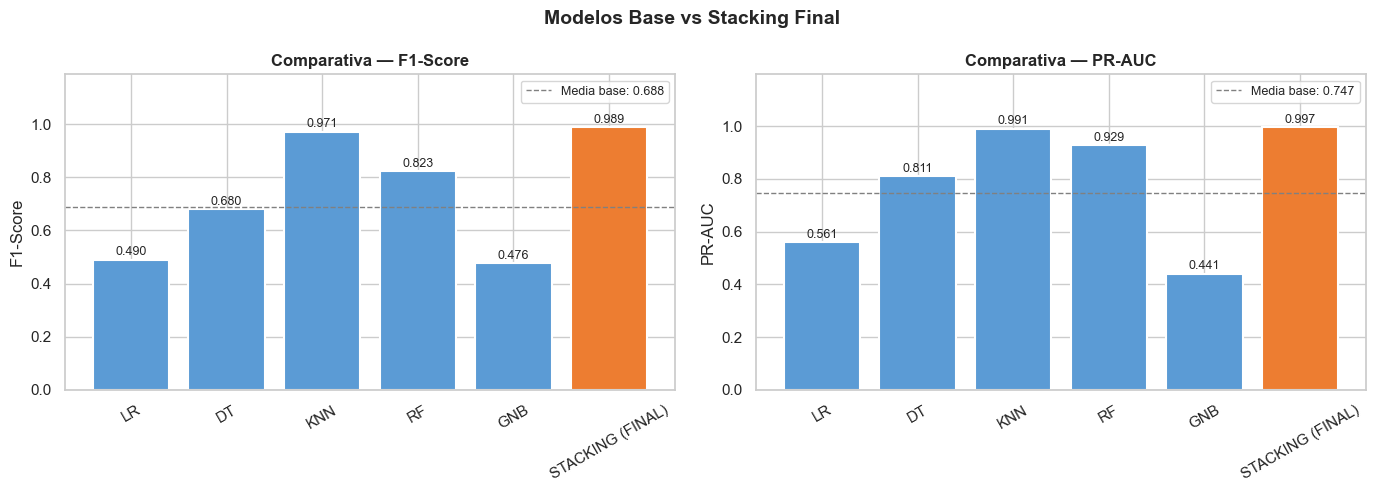

In [8]:
# Gráfico comparativo de métricas clave
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metricas_plot = ['F1-Score', 'PR-AUC']
colores = ['#5B9BD5' if idx != 'STACKING (FINAL)' else '#ED7D31'
           for idx in df_comparativa.index]

for ax, metrica in zip(axes, metricas_plot):
    bars = ax.bar(df_comparativa.index, df_comparativa[metrica],
                  color=colores, edgecolor='white', linewidth=1.5)
    ax.set_title(f'Comparativa — {metrica}', fontweight='bold', fontsize=12)
    ax.set_ylabel(metrica)
    ax.set_ylim(0, df_comparativa[metrica].max() * 1.2)
    ax.tick_params(axis='x', rotation=30)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=9)
    # Línea media de referencia
    media = df_comparativa[metrica].drop('STACKING (FINAL)').mean()
    ax.axhline(media, color='gray', linestyle='--', linewidth=1,
               label=f'Media base: {media:.3f}')
    ax.legend(fontsize=9)

plt.suptitle('Modelos Base vs Stacking Final', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Visualizaciones

### 8.1 Matriz de confusión

Verdaderos Negativos (TN):  31,824  — legítimas correctamente identificadas
Falsos Positivos   (FP):    176  — legítimas clasificadas como fraude (falsas alarmas)
Falsos Negativos   (FN):    2  — fraudes no detectados (más costosos)
Verdaderos Positivos (TP):  7,998  — fraudes correctamente detectados

Tasa de detección de fraude: 100.0%


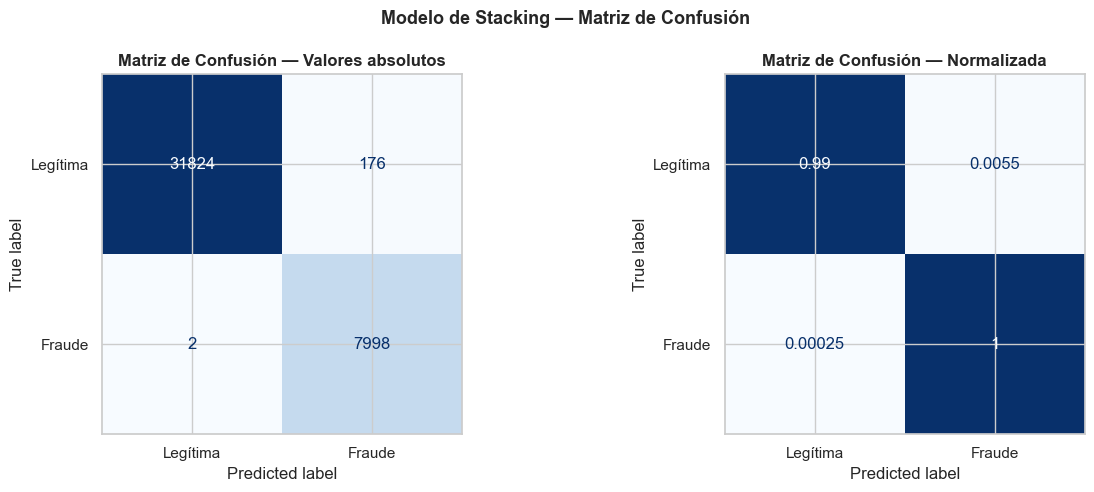

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz absoluta
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Legítima', 'Fraude'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión — Valores absolutos', fontweight='bold')

# Matriz normalizada
cm_norm = confusion_matrix(y_test, y_pred, normalize='true')
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                    display_labels=['Legítima', 'Fraude'])
disp_norm.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Matriz de Confusión — Normalizada', fontweight='bold')

# Anotaciones interpretativas
tn, fp, fn, tp = cm.ravel()
print(f'Verdaderos Negativos (TN):  {tn:,}  — legítimas correctamente identificadas')
print(f'Falsos Positivos   (FP):    {fp:,}  — legítimas clasificadas como fraude (falsas alarmas)')
print(f'Falsos Negativos   (FN):    {fn:,}  — fraudes no detectados (más costosos)')
print(f'Verdaderos Positivos (TP):  {tp:,}  — fraudes correctamente detectados')
print(f'\nTasa de detección de fraude: {tp/(tp+fn)*100:.1f}%')

plt.suptitle('Modelo de Stacking — Matriz de Confusión', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.2 Curva ROC

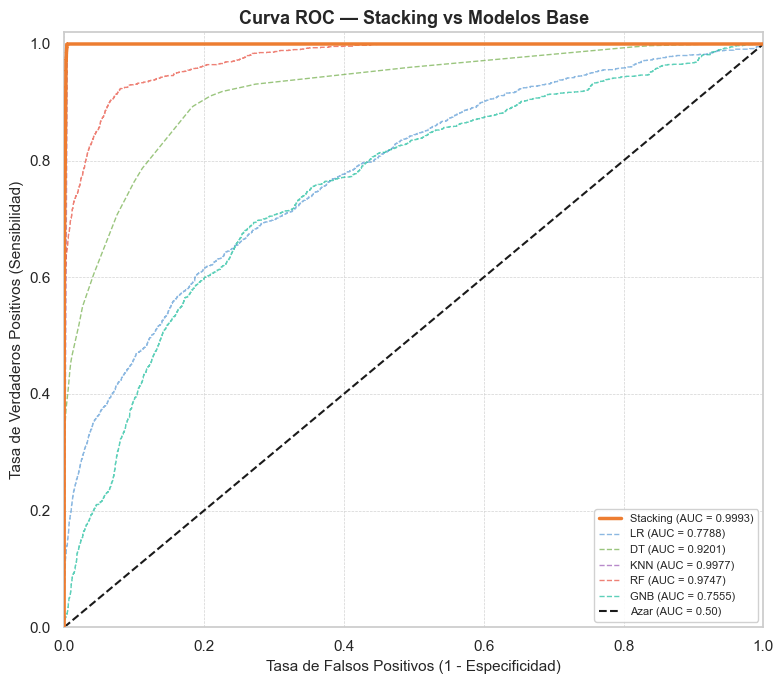

Curva ROC guardada en ../data/curva_roc.png


In [10]:
fig, ax = plt.subplots(figsize=(8, 7))

# Curva del Stacking
fpr_st, tpr_st, _ = roc_curve(y_test, y_proba)
ax.plot(fpr_st, tpr_st, color='#ED7D31', lw=2.5,
        label=f'Stacking (AUC = {roc_auc:.4f})', zorder=5)

# Curvas de cada modelo base
colores_base = ['#5B9BD5','#70AD47','#9B59B6','#E74C3C','#1ABC9C','#F39C12','#2980B9','#BDC3C7']
for (nombre, modelo), color in zip(stacking_model.named_estimators_.items(), colores_base):
    y_prob_i = modelo.predict_proba(X_test)[:, 1]
    fpr_i, tpr_i, _ = roc_curve(y_test, y_prob_i)
    auc_i = roc_auc_score(y_test, y_prob_i)
    ax.plot(fpr_i, tpr_i, lw=1, linestyle='--', color=color, alpha=0.7,
            label=f'{nombre.upper()} (AUC = {auc_i:.4f})')

# Línea de azar
ax.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Azar (AUC = 0.50)')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=11)
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=11)
ax.set_title('Curva ROC — Stacking vs Modelos Base', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
ax.grid(color='lightgray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('../data/curva_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Curva ROC guardada en ../data/curva_roc.png')

### 8.3 Curva Precision-Recall

En datasets desbalanceados, la curva PR es más informativa que la ROC, ya que se centra en el rendimiento sobre la clase minoritaria (fraude).

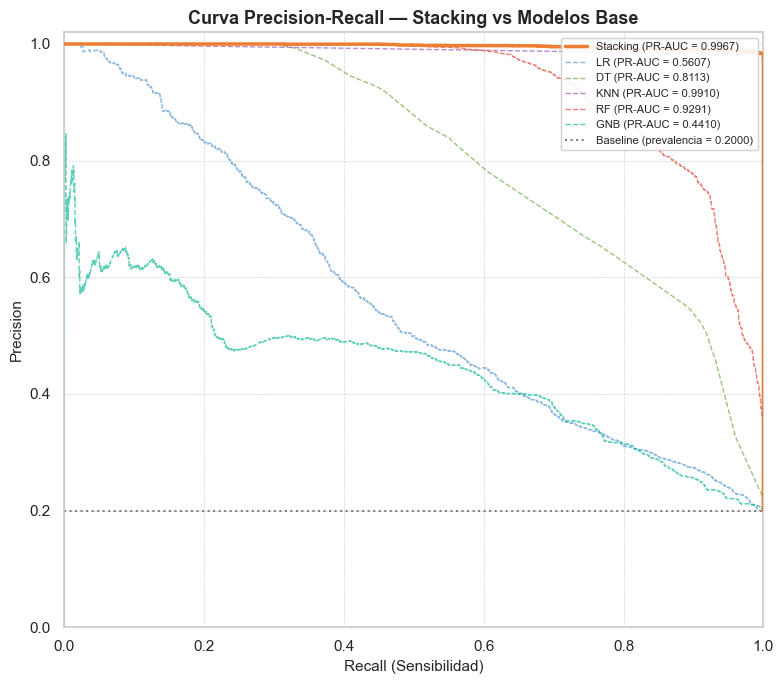

In [11]:
fig, ax = plt.subplots(figsize=(8, 7))

# Stacking
prec_st, rec_st, _ = precision_recall_curve(y_test, y_proba)
pr_auc_st = auc(rec_st, prec_st)
ax.plot(rec_st, prec_st, color='#ED7D31', lw=2.5,
        label=f'Stacking (PR-AUC = {pr_auc_st:.4f})', zorder=5)

# Modelos base
for (nombre, modelo), color in zip(stacking_model.named_estimators_.items(), colores_base):
    y_prob_i = modelo.predict_proba(X_test)[:, 1]
    prec_i, rec_i, _ = precision_recall_curve(y_test, y_prob_i)
    pr_i = auc(rec_i, prec_i)
    ax.plot(rec_i, prec_i, lw=1, linestyle='--', color=color, alpha=0.7,
            label=f'{nombre.upper()} (PR-AUC = {pr_i:.4f})')

# Baseline (prevalencia de fraude)
baseline = y_test.mean()
ax.axhline(baseline, color='gray', linestyle=':', lw=1.5,
           label=f'Baseline (prevalencia = {baseline:.4f})')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('Recall (Sensibilidad)', fontsize=11)
ax.set_ylabel('Precision', fontsize=11)
ax.set_title('Curva Precision-Recall — Stacking vs Modelos Base', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=8, framealpha=0.9)
ax.grid(color='lightgray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.savefig('../data/curva_pr.png', dpi=150, bbox_inches='tight')
plt.show()

### 8.4 Importancia de variables

Extraemos la importancia de variables de los modelos base que la soportan (Random Forest, Gradient Boosting, XGBoost y Árbol de Decisión).

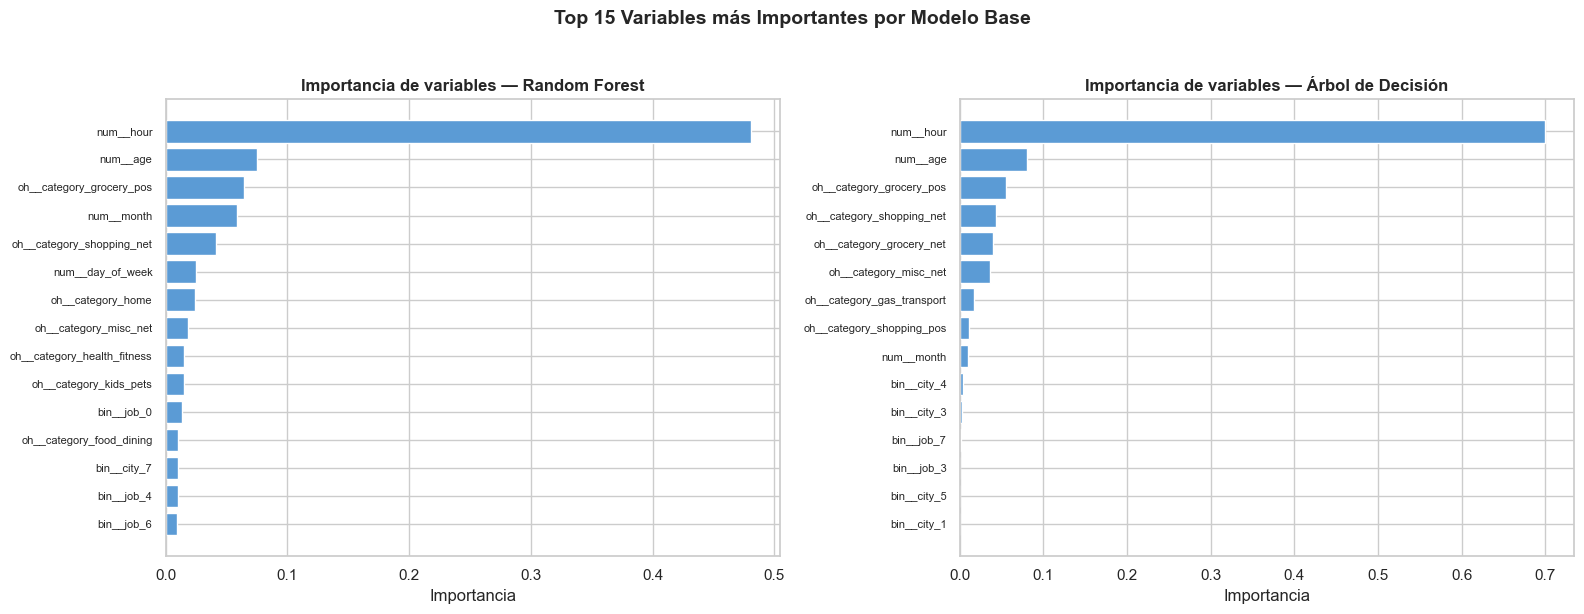

In [12]:
modelos_importancia = {
    'Random Forest':     stacking_model.named_estimators_['rf'],
    'Árbol de Decisión': stacking_model.named_estimators_['dt'],
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (nombre, modelo) in zip(axes, modelos_importancia.items()):
    importancias = modelo.feature_importances_
    feat_imp = pd.Series(importancias, index=feature_cols).sort_values(ascending=False).head(15)

    ax.barh(feat_imp.index[::-1], feat_imp.values[::-1],
            color='#5B9BD5', edgecolor='white')
    ax.set_title(f'Importancia de variables — {nombre}', fontweight='bold')
    ax.set_xlabel('Importancia')
    ax.tick_params(axis='y', labelsize=8)

plt.suptitle('Top 15 Variables más Importantes por Modelo Base',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

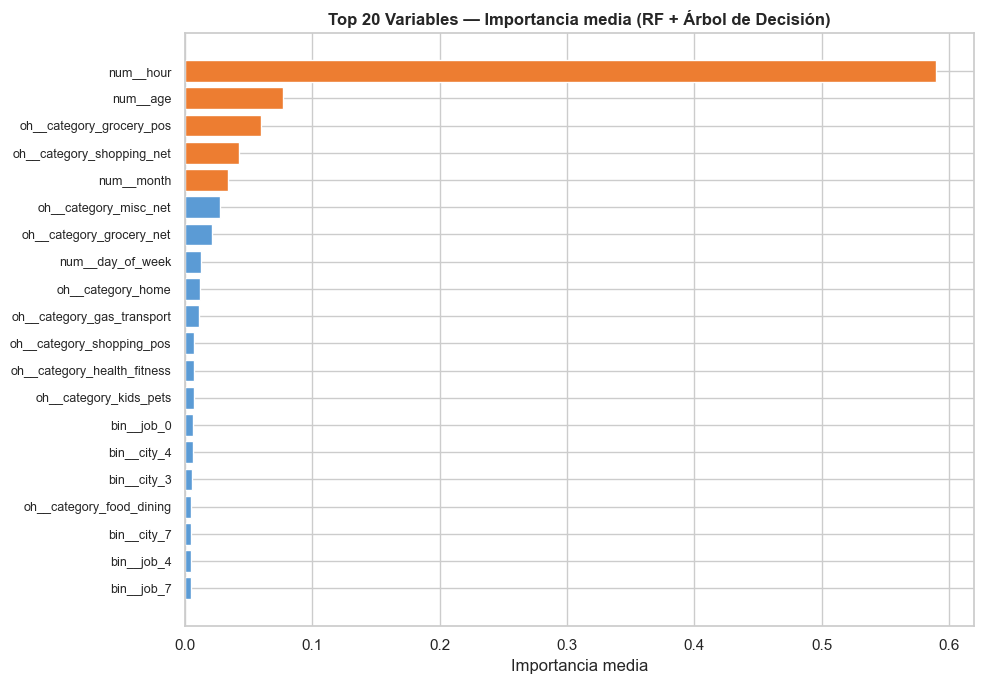

In [13]:
# Importancia media entre RF y Árbol de Decisión
imp_rf  = stacking_model.named_estimators_['rf'].feature_importances_
imp_dt  = stacking_model.named_estimators_['dt'].feature_importances_

imp_media = (imp_rf + imp_dt) / 2
feat_imp_media = pd.Series(imp_media, index=feature_cols).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(feat_imp_media.index[::-1], feat_imp_media.values[::-1],
        color=['#ED7D31' if i < 5 else '#5B9BD5' for i in range(len(feat_imp_media)-1, -1, -1)],
        edgecolor='white')
ax.set_title('Top 20 Variables — Importancia media (RF + Árbol de Decisión)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Importancia media')
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.show()

### 8.5 Análisis del umbral de decisión

En detección de fraude, el umbral de clasificación por defecto (0.5) no siempre es óptimo. Analizamos cómo varía la Precision y el Recall al ajustarlo.

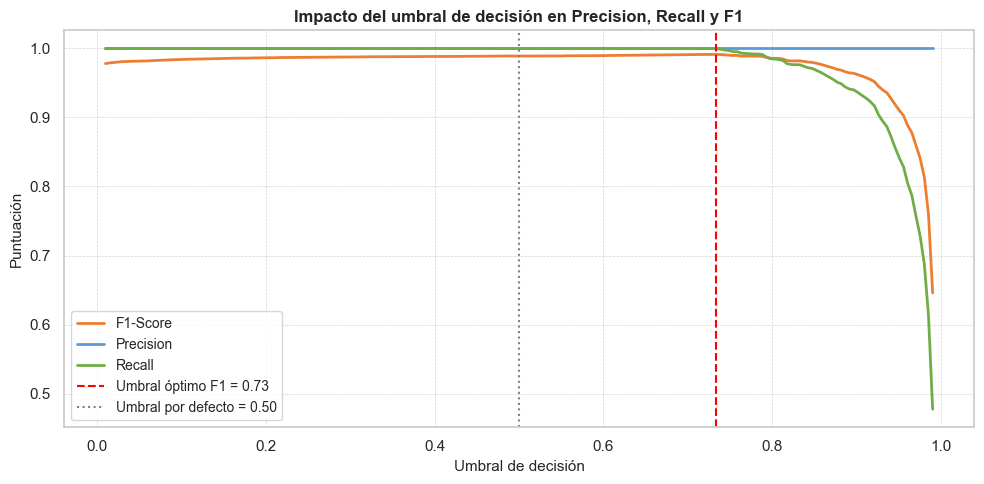

Umbral óptimo para F1-Score: 0.73
F1-Score con umbral óptimo:  0.9915
F1-Score con umbral 0.50:    0.9890


In [14]:
thresholds_range = np.linspace(0.01, 0.99, 200)
f1_scores, precisions, recalls = [], [], []

for thr in thresholds_range:
    y_pred_thr = (y_proba >= thr).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_thr, zero_division=0))
    precisions.append(pd.Series(y_pred_thr[y_pred_thr == 1]).shape[0] /
                      max(y_pred_thr.sum(), 1))
    from sklearn.metrics import recall_score
    recalls.append(recall_score(y_test, y_pred_thr, zero_division=0))

umbral_optimo = thresholds_range[np.argmax(f1_scores)]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds_range, f1_scores,   color='#ED7D31', lw=2, label='F1-Score')
ax.plot(thresholds_range, precisions,  color='#5B9BD5', lw=2, label='Precision')
ax.plot(thresholds_range, recalls,     color='#70AD47', lw=2, label='Recall')
ax.axvline(umbral_optimo, color='red', linestyle='--', lw=1.5,
           label=f'Umbral óptimo F1 = {umbral_optimo:.2f}')
ax.axvline(0.5, color='gray', linestyle=':', lw=1.5, label='Umbral por defecto = 0.50')
ax.set_xlabel('Umbral de decisión', fontsize=11)
ax.set_ylabel('Puntuación', fontsize=11)
ax.set_title('Impacto del umbral de decisión en Precision, Recall y F1',
             fontweight='bold', fontsize=12)
ax.legend(fontsize=10)
ax.grid(color='lightgray', linestyle='--', linewidth=0.5)
plt.tight_layout()
plt.show()

print(f'Umbral óptimo para F1-Score: {umbral_optimo:.2f}')
y_pred_opt = (y_proba >= umbral_optimo).astype(int)
print(f'F1-Score con umbral óptimo:  {f1_score(y_test, y_pred_opt):.4f}')
print(f'F1-Score con umbral 0.50:    {f1_score(y_test, y_pred):.4f}')

## 9. Resumen final

In [15]:
print('=' * 60)
print('   RESUMEN FINAL — MODELO DE STACKING')
print('=' * 60)
print(f'\n  Modelos base ({len(modelos_base)}):')
for nombre, _ in modelos_base:
    print(f'    · {nombre.upper()}')
print(f'\n  Metamodelo: LogisticRegression')
print(f'  Validación cruzada interna: 5-fold')
print(f'  Tratamiento desbalanceo: SMOTE (ratio 1:3)')
print(f'\n  Métricas sobre test ({len(y_test):,} muestras):')
print(f'    ROC-AUC:  {roc_auc_score(y_test, y_proba):.4f}')
print(f'    PR-AUC:   {average_precision_score(y_test, y_proba):.4f}')
print(f'    F1-Score: {f1_score(y_test, y_pred):.4f}')
print(f'    MCC:      {matthews_corrcoef(y_test, y_pred):.4f}')
print(f'\n  Umbral óptimo (F1): {umbral_optimo:.2f}')
print(f'  F1 con umbral óptimo: {f1_score(y_test, y_pred_opt):.4f}')
print('=' * 60)

   RESUMEN FINAL — MODELO DE STACKING

  Modelos base (5):
    · LR
    · DT
    · KNN
    · RF
    · GNB

  Metamodelo: LogisticRegression
  Validación cruzada interna: 5-fold
  Tratamiento desbalanceo: SMOTE (ratio 1:3)

  Métricas sobre test (40,000 muestras):
    ROC-AUC:  0.9993
    PR-AUC:   0.9967
    F1-Score: 0.9890
    MCC:      0.9863

  Umbral óptimo (F1): 0.73
  F1 con umbral óptimo: 0.9915


In [16]:
# Predicciones para ambos conjuntos
y_train_pred = stacking_model.predict(X_train)
y_test_pred = stacking_model.predict(X_test)

y_train_proba = stacking_model.predict_proba(X_train)[:, 1]
y_test_proba = stacking_model.predict_proba(X_test)[:, 1]

print("--- COMPARATIVA TRAIN VS TEST ---")
print(f"ROC-AUC Train: {roc_auc_score(y_train, y_train_proba):.4f} | Test: {roc_auc_score(y_test, y_test_proba):.4f}")
print(f"F1-Score Train: {f1_score(y_train, y_train_pred):.4f} | Test: {f1_score(y_test, y_test_pred):.4f}")
print(f"PR-AUC   Train: {average_precision_score(y_train, y_train_proba):.4f} | Test: {average_precision_score(y_test, y_test_proba):.4f}")

--- COMPARATIVA TRAIN VS TEST ---
ROC-AUC Train: 1.0000 | Test: 0.9993
F1-Score Train: 0.9994 | Test: 0.9890
PR-AUC   Train: 0.9999 | Test: 0.9967


In [21]:
from sklearn.metrics import f1_score, accuracy_score

# 1. Realizar predicciones para ambos conjuntos
y_train_pred = stacking_model.predict(X_train)
y_test_pred = stacking_model.predict(X_test) # Esta ya la tienes como y_pred en tu notebook

# 2. Calcular la métrica (usaremos F1-Score que es mejor para fraude)
f1_train = f1_score(y_train, y_train_pred)
f1_test = f1_score(y_test, y_test_pred)

# 3. Calcular la brecha (Gap)
# En métricas de éxito (como F1), una brecha positiva grande indica overfitting
gap = f1_train - f1_test

print(f"F1-Score Entrenamiento: {f1_train:.4f}")
print(f"F1-Score Test:          {f1_test:.4f}")
print(f"Brecha de Overfitting:  {gap:.4f}")

if gap > 0.10:
    print("\n⚠️ Riesgo de Overfitting detectado: La diferencia es superior al 10%.")
else:
    print("\n✅ El modelo parece generalizar bien.")

F1-Score Entrenamiento: 0.9994
F1-Score Test:          0.9890
Brecha de Overfitting:  0.0104

✅ El modelo parece generalizar bien.


Calculando overfitting por modelo...


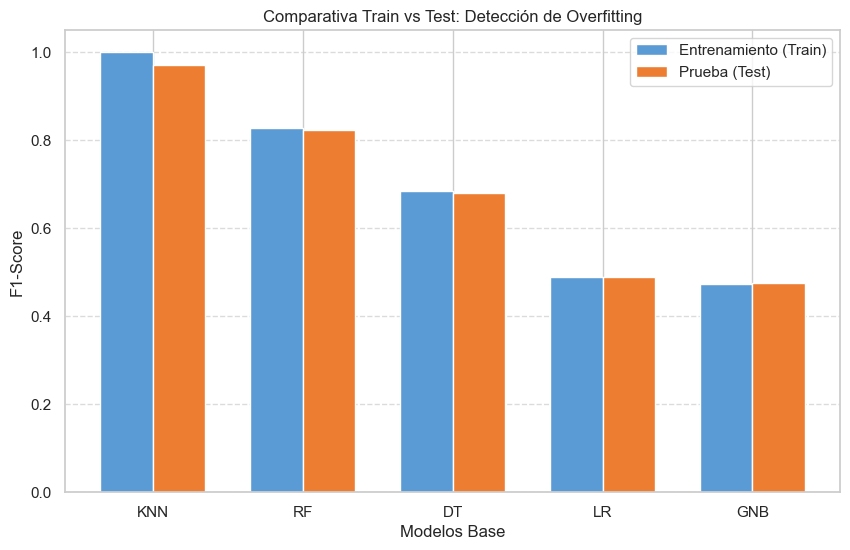

  Modelo  F1 Train   F1 Test       Gap
2    KNN  0.999781  0.971227  0.028554
3     RF  0.827911  0.823312  0.004598
1     DT  0.683685  0.680183  0.003502
0     LR  0.488388  0.489913 -0.001525
4    GNB  0.472865  0.476240 -0.003375


In [22]:


# Lista para guardar los resultados
of_results = []

print("Calculando overfitting por modelo...")

# Iteramos sobre los modelos base ya entrenados dentro del stacking
for nombre, modelo in stacking_model.named_estimators_.items():
    # Predicciones
    y_tr_pred = modelo.predict(X_train)
    y_te_pred = modelo.predict(X_test)
    
    # Calculamos F1-Score (es más preciso que Accuracy para fraude)
    f1_tr = f1_score(y_train, y_tr_pred)
    f1_te = f1_score(y_test, y_te_pred)
    
    of_results.append({
        'Modelo': nombre.upper(),
        'F1 Train': f1_tr,
        'F1 Test': f1_te,
        'Gap': f1_tr - f1_te
    })

# Convertimos a DataFrame y ordenamos por el mayor Gap
df_of = pd.DataFrame(of_results).sort_values(by='Gap', ascending=False)

# --- VISUALIZACIÓN ---
plt.figure(figsize=(10, 6))
x = range(len(df_of))
width = 0.35

plt.bar(x, df_of['F1 Train'], width, label='Entrenamiento (Train)', color='#5B9BD5')
plt.bar([i + width for i in x], df_of['F1 Test'], width, label='Prueba (Test)', color='#ED7D31')

plt.xlabel('Modelos Base')
plt.ylabel('F1-Score')
plt.title('Comparativa Train vs Test: Detección de Overfitting')
plt.xticks([i + width/2 for i in x], df_of['Modelo'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print(df_of)